In [106]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from typing import Optional, List, Dict, Any  # Import typing module with commonly used types

proj_src = pathlib.Path().resolve().parent.parent / "motec-ld-export-ui" / "motec-to-csv" / "src"
sys.path.append(str(proj_src))
from motec_converter import parse_race_data, to_pandas
sys.path.remove(str(proj_src))

In [38]:
import sys, pathlib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [186]:
def process_and_compute_efficiency(dyno_files, motec_files, target_torque=150,
                                   rpm_diff_tol=None, rolling_window=3, plot=True):
    """
    Process dyno and MoTeC data and compute motor efficiency.
    
    Parameters:
    - dyno_df: DataFrame with dyno data indexed by run ID
    - motec_files: list of MoTeC file paths
    - dyno_ids: list of corresponding dyno IDs for each MoTeC file
    - target_torque: torque to filter by (Nm)
    - rpm_diff_tol: if given, only match points within ±rpm_diff_tol
    - rolling_window: window for rolling mean smoothing
    - plot: if True, generate scatter plot of efficiency vs RPM
    
    Returns:
    - combined_df: concatenated DataFrame with efficiency calculations
    """
    
    all_runs = []
    i= 1
    for motec_file, dyno_file in zip(motec_files, dyno_files):
        print(i)
        i+=1
        # --- Load dyno ---
        #print(f'Dyno_Data/{dyno_file}')
        cur_dyno_df = pd.read_csv(f'Dyno_Data/{dyno_file}')
        cur_dyno_df = cur_dyno_df.dropna(subset=['Axle Speed (rpm)', 'Axle Torque (Nm)'])

        cur_dyno_df['Calculated Motor RPM'] = cur_dyno_df['Axle Speed (rpm)'] * 38/11
        cur_dyno_df['Calculated Motor Torque'] = cur_dyno_df['Axle Torque (Nm)'] * 11/38
        
        
        rpm_min = cur_dyno_df["Calculated Motor RPM"].min()
        rpm_max = cur_dyno_df["Calculated Motor RPM"].max()
        
        # --- Load MoTeC ---
        #motec_df = motec_files
        motec_df = pd.read_csv(f'Motec_Data/CSV Export/{motec_file}', header=8, low_memory=False)
        motec_df= motec_df.iloc[1:].reset_index(drop=True)
        motec_df = motec_df.apply(pd.to_numeric, errors='coerce')
        voltage_col = 'Car.Data.Inverter.InverterDCVoltage'
        current_col = 'Car.Data.Inverter.InverterDCCurrent'
        motec_df['Battery Power (kW)'] = (motec_df[voltage_col] * motec_df[current_col] / (100000))
        
        if not (motec_df[current_col] > 0).any():
            print("WARNING: No positive DC current detected. Skipping.")
            continue

            

        #print(rpm_min, rpm_max)
        
        # Filter by RPM range and target torque
        motec_trim = motec_df[
            (motec_df["Car.Data.Motor.MotorRPM"] >= rpm_min) &
            (motec_df["Car.Data.Motor.MotorRPM"] <= rpm_max) &
            (motec_df['Car.Data.Inverter.InverterCalculatedTorque'] >= target_torque) &
            (motec_df['Battery Power (kW)'] > 1)
            ].copy()
        
        # Only keep monotonic increasing RPM
        motec_trim = motec_trim[motec_trim["Car.Data.Motor.MotorRPM"].diff() > 0]
        
        # Rolling mean smoothing
        motec_trim = motec_trim.rolling(rolling_window).mean().dropna()

        # --- NEW SAFETY CHECK ---
        # If motec_trim is empty, skip this file and move to the next one
        if motec_trim.empty:
            print(f"Skipping {motec_file}: No data matches target torque/RPM criteria.")
            continue
        
        # --- Nearest neighbor matching ---
        dyno_features = cur_dyno_df[['Calculated Motor RPM', 'Calculated Motor Torque']].to_numpy()
        #print(dyno_features)
        motec_features = motec_trim[['Car.Data.Motor.MotorRPM', 'Car.Data.Inverter.InverterCalculatedTorque']].to_numpy()

        scaler = StandardScaler()
        dyno_features_scaled = scaler.fit_transform(dyno_features)
        motec_features_scaled = scaler.transform(motec_features)
        
        #print(motec_features)
        nn = NearestNeighbors(n_neighbors=1)
        nn.fit(dyno_features_scaled)
        distances, indices = nn.kneighbors(motec_features_scaled)
        
        matched_dyno = cur_dyno_df.iloc[indices.flatten()].reset_index(drop=True)
        matched_motec = motec_trim.reset_index(drop=True)
        
        # Optional RPM difference filter
        if rpm_diff_tol is not None:
            rpm_diff = np.abs(matched_dyno['Calculated Motor RPM'] - matched_motec['Car.Data.Motor.MotorRPM'])
            keep = rpm_diff <= rpm_diff_tol
            matched_dyno = matched_dyno[keep].reset_index(drop=True)
            matched_motec = matched_motec[keep].reset_index(drop=True)
        
        # --- Compute efficiency ---
        matched_df = matched_motec.copy()
        matched_df['P_out'] = matched_dyno['Calculated Motor Torque'] * 2 * np.pi * matched_dyno['Calculated Motor RPM'] / 60 / 1000
        matched_df['P_in'] = matched_motec['Battery Power (kW)']
        matched_df['eff'] = matched_df['P_out'] / matched_df['P_in']
        
        
        all_runs.append(matched_df)
    
    # --- Combine all runs ---
    combined_df = pd.concat(all_runs, ignore_index=True)
    combined_df = combined_df[(combined_df['eff'] < 1) & (combined_df['eff'] >0)]  # sanity filter
    
    # --- Plot ---
    if plot:
        plt.figure(figsize=(10,5))
        plt.scatter(combined_df['Car.Data.Motor.MotorRPM'], combined_df['eff'], s=5, alpha=0.7)
        plt.xlabel("RPM")
        plt.ylabel("Efficiency")
        plt.title(f"Motor Efficiency vs RPM (Torque = {target_torque} Nm)")
        plt.grid(True)
        plt.show()
    
    return combined_df

In [136]:
from pathlib import Path


folder = Path("Dyno_Data")

csv_files = [f.name for f in folder.glob('*.csv')]

print(csv_files)

['speedramp10_pl140_manual_dhruv.csv', 'speedramp11_pl150_manual_dhruv.csv', 'speedramp12_pl160_maual_dhruv_failed.csv', 'speedramp13_pl167-1_manual_dhruv_failed.csv', 'speedramp1_pl50_manual_dhruv.csv', 'speedramp2_pl60_manual_dhruv.csv', 'speedramp3_pl70_manual_dhruv.csv', 'speedramp4_pl80_manual_dhruv.csv', 'speedramp5_pl90_manual_dhruv.csv', 'speedramp6_pl100_manual_dhruv.csv', 'speedramp7_pl110_manual_dhruv.csv', 'speedramp8_pl120_manual_dhruv.csv', 'speedramp9_pl130_manual_dhruv.csv']


In [137]:
import re
def extract_run_number(filename):
    return int(re.search(r"speedramp(\d+)", filename).group(1))

# filter out 13, then sort
sorted_dyno_files = sorted(
    [f for f in csv_files if extract_run_number(f) <= 12],
    key=extract_run_number
)

print(sorted_dyno_files[0])

speedramp1_pl50_manual_dhruv.csv


In [138]:
df_test = pd.read_csv(f'Dyno_Data/{sorted_dyno_files[0]}', index_col=0, parse_dates=True)
df_test

,Axle Torque (Nm),Axle Speed (rpm),Power (kW),TqC (Nm),Time (sec),Tailshaft Speed (rpm),Speed (km/h),Tacho [Rat] (rpm),Speed L (rpm),Tq L (Nm),Speed R (rpm),Axle Tq R (Nm),Comments
Run Name,,,,,,,,,,,,,
MUREV2025.0028,142.5,756.52,11.249,43.506,1.30,2958.0,58.025,2469.1,759.0,97.5,754.1,45.0,NaN
MUREV2025.0028,142.5,755.80,11.252,43.562,1.35,2955.2,57.967,2466.7,758.2,98.0,753.4,44.5,NaN
MUREV2025.0028,142.5,756.00,11.229,43.500,1.40,2956.0,57.931,2465.2,758.4,98.5,753.6,44.0,NaN
MUREV2025.0028,142.5,756.52,11.226,43.498,1.45,2958.0,57.917,2464.6,759.0,98.5,754.0,44.0,NaN
MUREV2025.0028,142.0,757.60,11.200,43.380,1.50,2962.2,57.938,2465.5,760.2,98.5,755.0,43.5,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
MUREV2025.0028,149.0,1418.40,22.021,45.523,14.90,5545.9,108.554,4619.4,1418.8,39.5,1418.0,109.5,NaN
MUREV2025.0028,149.0,1414.56,21.996,45.512,14.95,5530.9,108.454,4615.1,1415.8,39.5,1413.3,109.5,NaN
MUREV2025.0028,148.5,1403.56,21.851,45.357,15.00,5487.9,108.108,4600.4,1407.2,39.0,1399.9,109.5,NaN


In [139]:
folder = Path("Motec_Data/CSV Export")

csv_motec_files = [f.name for f in folder.glob('*.csv')]

print(csv_motec_files)

['dryno_morning_torquemapping_withshudderissue_1.csv', 'dryno_morning_torquemapping_withshudderissue_2.csv', 'dryno_morning_torquemapping_withshudderissue_3.csv', 'dryno_morning_torquemapping_withshudderissue_4.csv', 'dryno_morning_torquemapping_withshudderissue_5.csv', 'dryno_morning_torquemapping_withshudderissue_6.csv', 'dryno_morning_torquemapping_withshudderissue_7.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_1.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_10.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_11.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_12.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_2.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_3.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_4.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_5.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_6.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_7.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_8.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_9.csv']


In [140]:
def extract_num(f):
    return int(re.search(r"_(\d+)\.csv", f).group(1))

# filter + sort
motec_sorted = sorted(
    [f for f in csv_motec_files if "dyno_arvo" in f],
    key=extract_num
)

print(motec_sorted)

['dyno_arvo_shudderfix_andlowrpmspeedramp_1.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_2.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_3.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_4.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_5.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_6.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_7.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_8.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_9.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_10.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_11.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_12.csv']


1
Skipping dyno_arvo_shudderfix_andlowrpmspeedramp_2.csv: No data matches target torque/RPM criteria.
2
Skipping dyno_arvo_shudderfix_andlowrpmspeedramp_3.csv: No data matches target torque/RPM criteria.
3
4
5
6
Skipping dyno_arvo_shudderfix_andlowrpmspeedramp_7.csv: No data matches target torque/RPM criteria.
7
Skipping dyno_arvo_shudderfix_andlowrpmspeedramp_8.csv: No data matches target torque/RPM criteria.
8
Skipping dyno_arvo_shudderfix_andlowrpmspeedramp_9.csv: No data matches target torque/RPM criteria.
9
Skipping dyno_arvo_shudderfix_andlowrpmspeedramp_10.csv: No data matches target torque/RPM criteria.
10
11


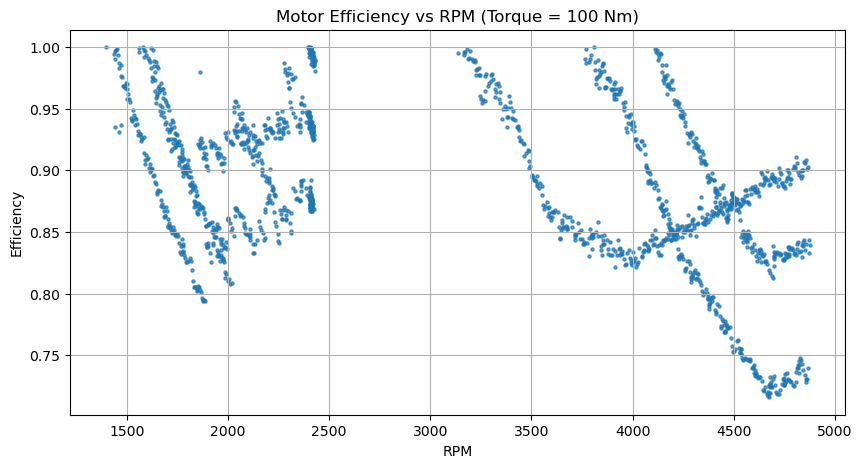

,Time,Car.DigitalInput.MSS.PDOC.Pin,Car.DigitalInput.MSS.BMS.Pin,Car.DigitalInput.MSS.BSPD.Pin,Car.DigitalInput.MSS.IMD.Pin,Car.Data.Driver.ThrottlePressure,Car.Data.Motor.MotorRPM,Car.AnalogInput.BMS.CellTempASensor,Car.AnalogInput.BMS.CellTempBSensor,Car.AnalogInput.BMS.CellTempCSensor,...,Car.Data.IMU.Rear.VelD,Car.Data.IMU.Rear.VelE,Car.Data.IMU.Rear.VelN,Car.DigitalInput.WheelSpeed.WheelSpeedFrontLeft,Car.DigitalInput.WheelSpeed.WheelSpeedFrontRight,Car.Data.Inverter.InverterCalculatedTorque,Battery Power (kW),P_out,P_in,eff
603,1067.046667,0.0,0.0,0.0,0.0,100.000000,3763.333333,1.603323,0.011181,1.611547,...,0.0,0.0,0.0,0.0,0.0,110.0,38.832530,38.447940,38.832530,0.990096
604,1067.063333,0.0,0.0,0.0,0.0,100.000000,3767.333333,1.602413,0.011090,1.611793,...,0.0,0.0,0.0,0.0,0.0,110.0,38.964110,38.447940,38.964110,0.986753
605,1067.090000,0.0,0.0,0.0,0.0,100.000000,3772.000000,1.601333,0.010978,1.612390,...,0.0,0.0,0.0,0.0,0.0,110.0,38.500603,38.447940,38.500603,0.998632
608,1067.150000,0.0,0.0,0.0,0.0,100.000000,3784.000000,1.600520,0.010863,1.614600,...,0.0,0.0,0.0,0.0,0.0,110.0,38.922147,38.447940,38.922147,0.987817
609,1067.170000,0.0,0.0,0.0,0.0,100.000000,3788.333333,1.600560,0.010853,1.615510,...,0.0,0.0,0.0,0.0,0.0,110.0,38.833007,38.447940,38.833007,0.990084
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4248,3643.830000,0.0,0.0,0.0,0.0,99.000000,2403.000000,1.496873,0.014653,1.500407,...,0.0,0.0,0.0,0.0,0.0,166.0,35.669950,31.108283,35.669950,0.872115
4249,3643.850000,0.0,0.0,0.0,0.0,99.000000,2399.666667,1.496663,0.014671,1.500413,...,0.0,0.0,0.0,0.0,0.0,166.0,35.389090,31.108283,35.389090,0.879036
4250,3643.870000,0.0,0.0,0.0,0.0,99.000000,2397.666667,1.496453,0.014689,1.500420,...,0.0,0.0,0.0,0.0,0.0,166.0,35.372730,31.108283,35.372730,0.879443
4251,3643.893333,0.0,0.0,0.0,0.0,93.333333,2405.666667,1.497763,0.014362,1.501387,...,0.0,0.0,0.0,0.0,0.0,161.0,35.136230,31.108283,35.136230,0.885362


In [192]:
motec_ld = parse_race_data("Motec_Data/CSV Export/dryno_morning_torquemapping_withshudderissue.ld")
segments = to_pandas(motec_ld)

motec_df = pd.concat(segments)

process_and_compute_efficiency(sorted_dyno_files[1:], motec_sorted[1:], target_torque=100, rpm_diff_tol=None, rolling_window=3, plot=True)

In [56]:
motec_df.columns

Index(['Car.DigitalInput.MSS.PDOC.Pin', 'Car.DigitalInput.MSS.BMS.Pin',
       'Car.DigitalInput.MSS.BSPD.Pin', 'Car.DigitalInput.MSS.IMD.Pin',
       'Car.Data.Driver.ThrottlePressure', 'Car.Data.Motor.MotorRPM',
       'Car.AnalogInput.BMS.CellTempASensor',
       'Car.AnalogInput.BMS.CellTempBSensor',
       'Car.AnalogInput.BMS.CellTempCSensor', 'Car.Data.Battery.PackSOC',
       'Car.Data.PDM.LVBatteryVoltage', 'Car.Data.Battery.BMSInternalTemp',
       'Car.Data.Inverter.InverterTemp', 'Car.Data.Motor.MotorTemp',
       'Car.Data.Inverter.InverterLock', 'Car.Data.Driver.SteeringAngle',
       'Car.Data.Shockpot.FrontLeft', 'Car.Data.Shockpot.FrontRight',
       'Car.Data.Shockpot.BackLeft', 'Car.Data.Shockpot.BackRight',
       'Car.Data.Driver.FrontBrakePressure',
       'Car.Data.Driver.RearBrakePressure',
       'Car.Data.Driver.ThrottleDifference', 'Car.Data.Battery.HotSpotTemp',
       'Car.Data.Water.WaterPressureIn', 'Car.Data.Water.WaterPressureOut',
       'Car.Data.Wate

In [97]:
trim_current= motec_df[motec_df['Car.Data.Inverter.InverterDCCurrent']>0]
trim_current[trim_current['Car.Data.Inverter.InverterCalculatedTorque']>100]

,Car.DigitalInput.MSS.PDOC.Pin,Car.DigitalInput.MSS.BMS.Pin,Car.DigitalInput.MSS.BSPD.Pin,Car.DigitalInput.MSS.IMD.Pin,Car.Data.Driver.ThrottlePressure,Car.Data.Motor.MotorRPM,Car.AnalogInput.BMS.CellTempASensor,Car.AnalogInput.BMS.CellTempBSensor,Car.AnalogInput.BMS.CellTempCSensor,Car.Data.Battery.PackSOC,...,Car.Data.IMU.Rear.AccelX,Car.Data.IMU.Rear.GyroZ,Car.Data.IMU.Rear.GyroY,Car.Data.IMU.Rear.GyroX,Car.Data.IMU.Rear.VelD,Car.Data.IMU.Rear.VelE,Car.Data.IMU.Rear.VelN,Car.DigitalInput.WheelSpeed.WheelSpeedFrontLeft,Car.DigitalInput.WheelSpeed.WheelSpeedFrontRight,Car.Data.Inverter.InverterCalculatedTorque
Time,,,,,,,,,,,,,,,,,,,,,
2024.16,0.0,0.0,0.0,0.0,86.0,1385.0,1.680213,0.008001,1.698667,67.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,115.0
2024.17,0.0,0.0,0.0,0.0,94.0,1423.0,1.680588,0.008834,1.699319,67.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,120.0
2024.18,0.0,0.0,0.0,0.0,97.0,1468.0,1.680963,0.009667,1.699972,67.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,120.0
2024.19,0.0,0.0,0.0,0.0,99.0,1468.0,1.681338,0.010501,1.700624,67.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,120.0
2024.20,0.0,0.0,0.0,0.0,100.0,1512.0,1.681713,0.011334,1.701277,67.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,120.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2641.88,0.0,0.0,0.0,0.0,100.0,2332.0,1.583207,0.014931,1.594897,57.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,140.0
2641.89,0.0,0.0,0.0,0.0,100.0,2329.0,1.583393,0.014931,1.594286,57.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,140.0
2641.90,0.0,0.0,0.0,0.0,100.0,2317.0,1.583580,0.014931,1.593675,57.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,140.0


In [124]:
print(sorted_dyno_files[8])
dyno_df = pd.read_csv(f'Dyno_Data/{sorted_dyno_files[8]}', parse_dates=True)

speedramp9_pl130_manual_dhruv.csv


<Axes: >

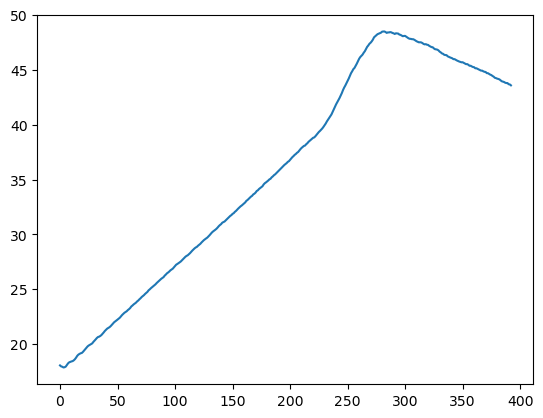

In [174]:
#(dyno_df['Axle Speed (rpm)']*38/11).
(dyno_df['Axle Torque (Nm)'] * 2 * np.pi * dyno_df['Axle Speed (rpm)'] / 60 / 1000).plot()

In [172]:
print(motec_sorted[8])
df_test = pd.read_csv(f'Motec_Data/CSV Export/{motec_sorted[8]}', header=8)

# drop the units row
df_test = df_test.iloc[1:].reset_index(drop=True)

dyno_arvo_shudderfix_andlowrpmspeedramp_9.csv


C:\Users\kafle\AppData\Local\Temp\ipykernel_28012\3496481642.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv(f'Motec_Data/CSV Export/{motec_sorted[8]}', header=8)


<Axes: >

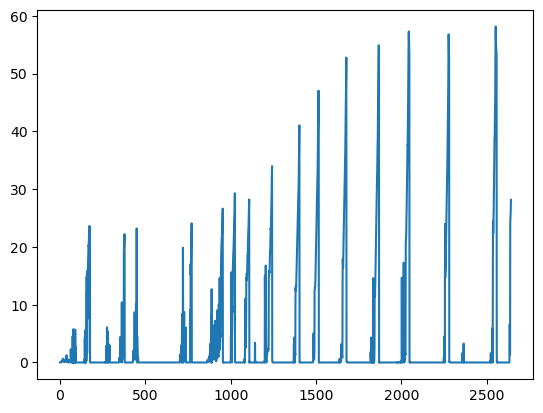

In [182]:
voltage_col = 'Car.Data.Inverter.InverterDCVoltage'
current_col = 'Car.Data.Inverter.InverterDCCurrent'
df_test['Battery Power (kW)'] = (motec_df[voltage_col] * motec_df[current_col] / (100000))

df_test['Battery Power (kW)'].plot()